In [116]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [117]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [118]:
def swissRoll(samples=1024, noise=0.0):
    t = 1.5 * 3.14 * (1 + 2 * torch.rand(samples, 1))
    x = t * torch.cos(t)
    y = t * torch.sin(t)
    X = torch.concat([x, y], axis=1)
    if noise > 0:
        X += noise * torch.randn(samples, 2)
    return X

In [119]:
class NaiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

In [120]:
naive_model = NaiveModel().to(device)
opt_naive = torch.optim.Adam(naive_model.parameters(), lr=1e-3)

Training Models:   0%|          | 0/1000 [00:00<?, ?it/s]

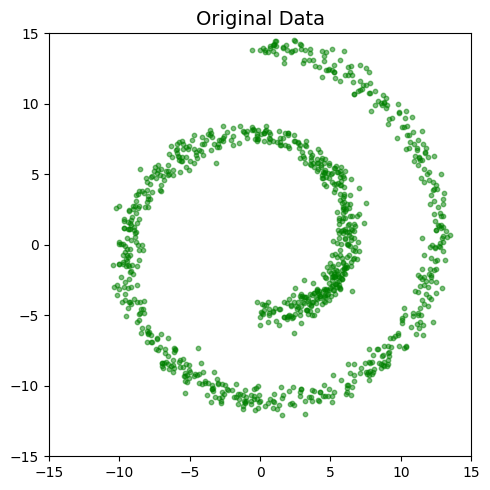

In [121]:
epochs = 1000
pbar = tqdm(range(epochs), desc="Training Models")

for i in pbar:
    real_data = swissRoll(1024, 0.5).to(device)
    opt_naive.zero_grad()
    random_noise = torch.randn(1024, 2).to(device)
    naive_pred = naive_model(random_noise)
    loss_naive = nn.functional.mse_loss(naive_pred, real_data)
    loss_naive.backward()
    opt_naive.step()


real_plot_data = swissRoll(1000, 0.5).cpu().numpy()

test_noise = torch.randn(1000, 2).to(device)

with torch.no_grad():
    naive_plot_data = naive_model(test_noise).cpu().numpy()


# fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# axs[0].scatter(real_plot_data[:, 0], real_plot_data[:, 1], s=10, alpha=0.5, color='green')
# axs[0].set_title("Original Data", fontsize=14)
# axs[0].set_xlim(-15, 15); axs[0].set_ylim(-15, 15)

# axs[1].scatter(naive_plot_data[:, 0], naive_plot_data[:, 1], s=10, alpha=0.5, color='red')
# axs[1].set_title("Naive Generated", fontsize=14)
# axs[1].set_xlim(-15, 15); axs[1].set_ylim(-15, 15)


# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(real_plot_data[:, 0], real_plot_data[:, 1], s=10, alpha=0.5, color='green')
ax.set_title("Original Data", fontsize=14)
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
plt.tight_layout()
plt.show()

In [122]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,4),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,2),
        )
    def forward(self, z):
        return self.net(z)

In [123]:
def sample_latent(latent):
    mean=latent[:,:2]
    logVar=latent[:,2:]
    std=torch.exp(0.5*logVar)
    latentSample=mean+std*torch.randn_like(std)
    kl = mean**2 + logVar.exp() - logVar - 1
    return latentSample,kl

In [124]:
encoder = Encoder().to(device)
decoder = Decoder().to(device)

opt_D = torch.optim.Adam(decoder.parameters(), lr=1e-3)
opt_E = torch.optim.Adam(encoder.parameters(), lr=1e-3)

epochs = 1000
pbar = tqdm(range(epochs), desc="Training VAE")

loss_vae = 0.0

for i in pbar:
    real_data = swissRoll(1024, 0.5).to(device)

    opt_D.zero_grad()
    opt_E.zero_grad()

    latent = encoder(real_data)
    latentSample, klLoss = sample_latent(latent)

    vae_pred = decoder(latentSample)
    reconstructionLoss = nn.functional.mse_loss(vae_pred, real_data)
    loss_vae = reconstructionLoss + 0.1 * klLoss.mean()

    loss_vae.backward()
    opt_E.step()
    opt_D.step()

    if i%100==0:
        print({'Loss':loss_vae.item()})

decoder.eval()
test_noise = torch.randn(1000, 2).to(device)
with torch.no_grad():
    vae_plot_data = decoder(test_noise).cpu().numpy()

# fig, ax = plt.subplots(figsize=(5, 5))
# ax.scatter(vae_plot_data[:, 0], vae_plot_data[:, 1], s=10, alpha=0.5, color='orange')
# ax.set_title("VAE Generated", fontsize=14)
# ax.set_xlim(-15, 15)
# ax.set_ylim(-15, 15)
# plt.tight_layout()
# plt.show()

Training VAE:   0%|          | 0/1000 [00:00<?, ?it/s]

{'Loss': 50.32661056518555}
{'Loss': 8.445043563842773}
{'Loss': 1.3157958984375}
{'Loss': 0.8432294130325317}
{'Loss': 0.7203248739242554}
{'Loss': 0.763358473777771}
{'Loss': 0.671319305896759}
{'Loss': 0.7068172693252563}
{'Loss': 0.7318253517150879}
{'Loss': 0.7015271782875061}


**VAE:** In your VAE, the model used Mean Squared Error (MSE). MSE is a strict, mathematical formula. If the VAE guessed a point slightly off the real spiral, MSE punished it heavily. To avoid this punishment, the VAE learned to "play it safe" and output points in the middle of the spiral arms, resulting in a blurry, interconnected blob.

**Generative Adversarial Networks (GANs):** Instead of using a fixed math formula (like MSE) for the loss, GANs use a second neural network (the Discriminator) to act as the loss function. It forces the Generator to output crisp, highly realistic data.

In [125]:
latent_dim = 16
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1) # Real vs Fake
        )
    def forward(self, x):
        return self.net(x)

In [126]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

opt_Gen = torch.optim.Adam(generator.parameters(), lr=1e-3, betas=(0.5, 0.999))
opt_Dis = torch.optim.Adam(discriminator.parameters(), lr=2e-3, betas=(0.5, 0.999))

epochs = 1000
pbar = tqdm(range(epochs), desc="Training GAN")

for i in pbar:
    for _ in range(2):
        real_data = swissRoll(1024, 0.5).to(device)

        opt_Dis.zero_grad()
        z = torch.randn(1024, latent_dim).to(device)
        fake_data = generator(z).detach()

        d_real = discriminator(real_data)
        d_fake = discriminator(fake_data)

        loss_D = torch.nn.functional.relu(1.0 - d_real).mean() + torch.nn.functional.relu(1.0 + d_fake).mean()
        loss_D.backward()
        opt_Dis.step()

    opt_Gen.zero_grad()
    z = torch.randn(1024, latent_dim).to(device)
    fake_data = generator(z)

    d_fake_for_G = discriminator(fake_data)
    # loss_G = nn.functional.relu(1.0 - d_fake_for_G).mean()
    loss_G = -d_fake_for_G.mean()

    loss_G.backward()
    opt_Gen.step()

    if i%100==0:
        print({'Loss':loss_G.item()})

generator.eval()
test_noise = torch.randn(1000, latent_dim).to(device)

with torch.no_grad():
    gan_plot_data = generator(test_noise).cpu().numpy()
    real_plot_data = swissRoll(1000, 0.5).numpy()

# fig, ax = plt.subplots(figsize=(5, 5))

# ax.scatter(gan_plot_data[:, 0], gan_plot_data[:, 1], s=10, alpha=0.5, color='purple')
# ax.set_title("GAN Generated", fontsize=14)
# ax.set_xlim(-15, 15)
# ax.set_ylim(-15, 15)

# plt.tight_layout()
# plt.show()

Training GAN:   0%|          | 0/1000 [00:00<?, ?it/s]

{'Loss': -0.0038110418245196342}
{'Loss': 1.1588499546051025}
{'Loss': 0.2650551199913025}
{'Loss': -0.209833562374115}
{'Loss': -0.14287200570106506}
{'Loss': -0.01908697932958603}
{'Loss': 0.05342165380716324}
{'Loss': 0.2625695466995239}
{'Loss': 0.21404804289340973}
{'Loss': 0.04524149373173714}


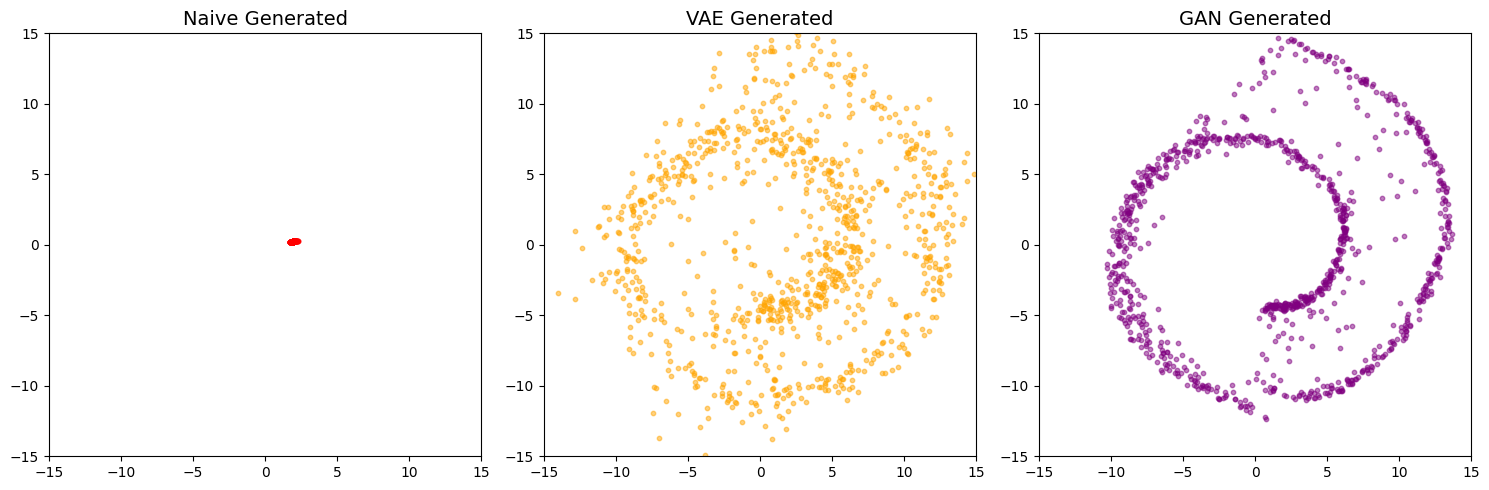

In [127]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(naive_plot_data[:, 0], naive_plot_data[:, 1], s=10, alpha=0.5, color='red')
axs[0].set_title("Naive Generated", fontsize=14)
axs[0].set_xlim(-15, 15)
axs[0].set_ylim(-15, 15)

axs[1].scatter(vae_plot_data[:, 0], vae_plot_data[:, 1], s=10, alpha=0.5, color='orange')
axs[1].set_title("VAE Generated", fontsize=14)
axs[1].set_xlim(-15, 15)
axs[1].set_ylim(-15, 15)

axs[2].scatter(gan_plot_data[:, 0], gan_plot_data[:, 1], s=10, alpha=0.5, color='purple')
axs[2].set_title("GAN Generated", fontsize=14)
axs[2].set_xlim(-15, 15)
axs[2].set_ylim(-15, 15)


plt.tight_layout()
plt.show()